# Univariate LSTM model (B)

**Directly predict *near-term* volatility (only) from historical return and volatility.**

Author: Pete King

This notebook uses financial data to train a univariate Long Short-Term Memory (LSTM) model to predict ***near-term*** **volatility** for a single of ETF representing a market sector, using only the ETF's historical return and volatility as input.

The purpose of this notebook is to establish a baseline for an LSTM's ability to predict the next value in a financial time series using limited input.  Subsequent multivariate LSTM models will incorporate additional features, and we will compare performance to asses the degree to which additional features help or hinder a model's ability to predict future financial performance.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler

import data_prep as dp
import models

# Global variables
DATA_FILENAME = 'train_val_data.csv'
TICKER = 'SPY'
WINDOW_SIZE = 5  # Size of the rolling window for historical volatility
OUTLOOK = 5  # Future outlook (no. bdays) for predicted future volatility
VALIDATION_START_DATE = '2023-01-01'
BUFFER_SIZE = 0  # Number of business days between train and validation sets
SEQUENCE_LENGTH = 21  # No. observations in each input sequence to LSTM
BATCH_SIZE = 10  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
df = pd.read_csv(
    DATA_FILENAME,
    index_col='date',
    parse_dates=True
)
df

,BIL,BND,GLD,HYG,IEF,IWM,LQD,QQQ,SPY,TIP,...,XLB_return,XLE_return,XLF_return,XLI_return,XLK_return,XLP_return,XLRE_return,XLU_return,XLV_return,XLY_return
date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.241400,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.413815,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.465536,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.724159,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.827616,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-24,86.178871,71.128273,246.070007,73.447990,93.066467,216.896286,106.184669,482.143372,562.774902,106.529709,...,0.013563,-0.002472,-0.008398,0.007158,0.006821,-0.002410,0.000000,-0.007121,-0.002010,0.008720
2024-09-25,86.197647,70.863937,245.729996,73.365479,92.688400,214.250748,105.557747,482.590363,561.533630,106.125992,...,-0.006706,-0.019767,-0.006010,-0.004692,0.002858,-0.002537,-0.004245,0.005252,-0.009782,-0.003599
2024-09-26,86.197647,70.863937,246.979996,73.484673,92.622238,215.392410,105.557747,486.216095,563.760010,105.991409,...,0.020499,-0.019814,0.005122,0.004989,0.013157,0.002295,-0.009899,-0.006883,0.003337,0.004248


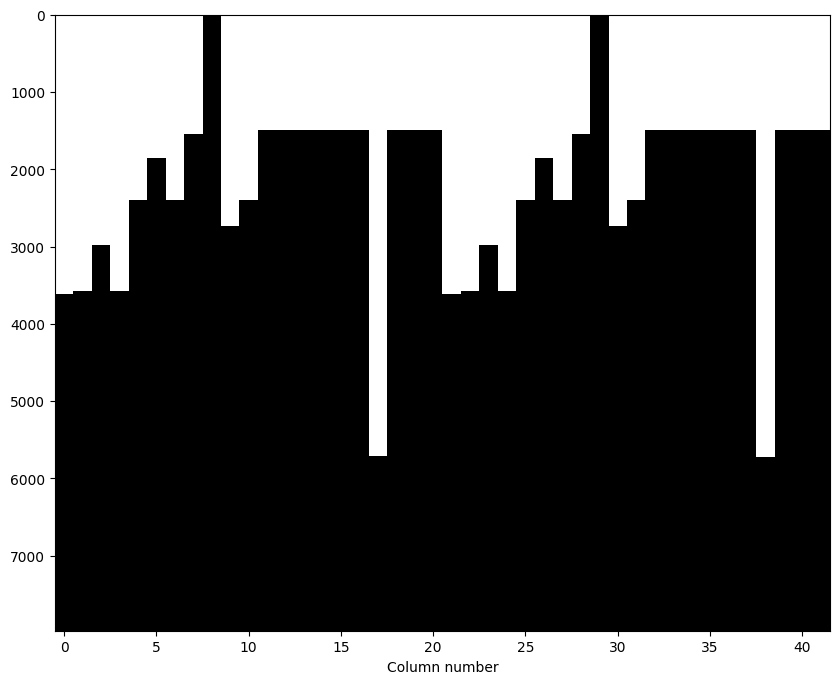

In [3]:
dp.view_nan(df);

### Create features and labels

For this investigation, we will use historical return and volatility as input features, with a target of future volatility.

In [4]:
# Select desired ETF (return data only)
etf_return = df[TICKER + '_return'].dropna().copy()
etf_df = pd.DataFrame(etf_return)
# Calculate historical volatility
etf_df[TICKER + '_h-vol'] = (
    etf_return.rolling(WINDOW_SIZE).apply(dp.volatility, raw=True)
)
# Assign future volatility target
etf_df[TICKER + '_f-vol_target'] = (
    etf_return.shift(-OUTLOOK).rolling(OUTLOOK).apply(dp.volatility, raw=True)
)

### Split data into training and validation sets

In [5]:
# Split the data
train_df, val_df = dp.time_series_split(
    etf_df, VALIDATION_START_DATE, BUFFER_SIZE
)
train_df

,SPY_return,SPY_h-vol,SPY_f-vol_target
date,,,
1993-02-01,0.007087,NaN,NaN
1993-02-02,0.002116,NaN,NaN
1993-02-03,0.010515,NaN,NaN
1993-02-04,0.004176,NaN,NaN
1993-02-05,-0.000694,0.006053,0.005165
...,...,...,...
2022-12-23,0.005736,0.010335,0.010149
2022-12-27,-0.003951,0.009769,0.010569
2022-12-28,-0.012506,0.011240,0.010334


In [6]:
val_df

,SPY_return,SPY_h-vol,SPY_f-vol_target
date,,,
2023-01-03,-0.004219,0.010149,0.012281
2023-01-04,0.007691,0.010569,0.013061
2023-01-05,-0.011479,0.010334,0.012119
2023-01-06,0.022673,0.012081,0.006860
2023-01-09,-0.000567,0.012026,0.006905
...,...,...,...
2024-09-24,0.002857,0.007906,NaN
2024-09-25,-0.002208,0.007856,NaN
2024-09-26,0.003957,0.002754,NaN


## II. PyTorch Multivariate LSTM Model

In this section we use the PyTorch library to create Datasets and DataLoaders that we will use to introduce training samples to the LSTM model in batches.

We use a custom Dataset for time series data.  The Dataset implements a rolling window that captures a series of data points from time (t - L) to time (t - 1), where L is the size of the rolling window (i.e., sequence length).  Thus each data sample is a matrix with dimensions (num_features, L), where num_features is the number of features in each data instance.

Our goal is to predict future volatility, but what remains unknown is how far into the future we should try to predict.  In this investigation, we will vary the size of the future-looking window for volatility and examine the empirical results.

### Create Datasets and DataLoaders

For the initial investigation, we try to predict the *current day's volatility* using past observations.

*Note: PyTorch LSTM models require input to use datatype 'np.float32'*

In [7]:
data_cols = ['SPY_return', 'SPY_h-vol']
label_col = ['SPY_f-vol_target']
# Model Training
train_dataset = dp.FinancialDataset(
    train_df.dropna()[data_cols].astype(np.float32).values,
    train_df.dropna()[label_col].astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    val_df.dropna()[data_cols].astype(np.float32).values,
    val_df.dropna()[label_col].astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [8]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([21, 2])
Shape of first training label: torch.Size([1])


In [9]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([10, 21, 2])
Shape of first batch of labels: torch.Size([10, 1])


### Instantiate and train LSTM model

In [10]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 32  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [11]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [12]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(2, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [13]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [14]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.003958212211728096
Validation loss: 0.008654800243675709
Epoch 20
Training loss:   0.004481158219277859
Validation loss: 0.009291200898587704
Epoch 30
Training loss:   0.004345584195107222
Validation loss: 0.008652581833302975
Epoch 40
Training loss:   0.004079916514456272
Validation loss: 0.007755700498819351
Epoch 50
Training loss:   0.0041717165149748325
Validation loss: 0.007596348412334919
Epoch 60
Training loss:   0.003976929932832718
Validation loss: 0.007318461313843727
Epoch 70
Training loss:   0.004223444499075413
Validation loss: 0.007553332019597292
Epoch 80
Training loss:   0.0040683988481760025
Validation loss: 0.007208711002022028
Epoch 90
Training loss:   0.004239213652908802
Validation loss: 0.007402738090604544
Epoch 100
Training loss:   0.0042915730737149715
Validation loss: 0.007368859834969044


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


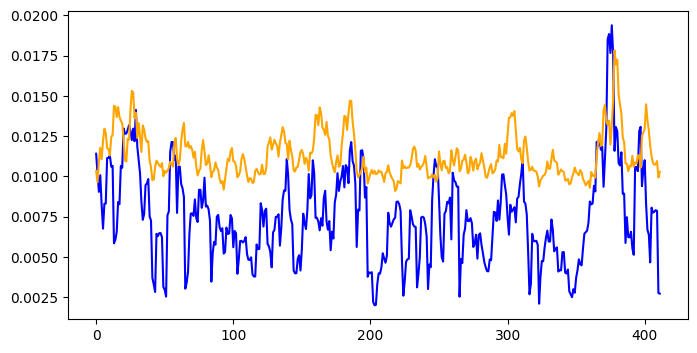

In [15]:
fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')

These results look promising!  Starting to believe we are on the right track with predicting volatility.  With some tuning we may be able to improve results.

I have serious doubts about using historical returns to predict future returns, however.  For now I think we should focus on predicting volatility.